# Postprocessing: Diagnostics

Loads summary CSV and inspects artifacts for a single run (nuisance fit diagnostics).


In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:

import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_summary(path):
    rows = []
    with open(path, newline='', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows

def as_float(x):
    try:
        return float(x)
    except Exception:
        return float('nan')

def summarize_rows(rows, n=5):
    print(f'Total rows: {len(rows)}')
    for r in rows[:n]:
        print({k: r.get(k) for k in ['run_id','method','dgp','rep','seed','status','artifacts_dir']})

def filter_rows_with_artifacts(rows):
    return [r for r in rows if r.get('artifacts_dir')]


def normalize_artifacts_dir(artifacts_dir):
    p = Path(artifacts_dir)
    if p.exists():
        return str(p)
    s = str(p).replace('\\', '/')
    linux_root = '/home/javureke/projects/Generalized-Bayes-for-CI'
    if s.startswith(linux_root):
        candidate = Path(s.replace(linux_root, str(Path.cwd())))
        if candidate.exists():
            return str(candidate)
    marker = '/results/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        candidate = Path.cwd() / 'results' / suffix
        if candidate.exists():
            return str(candidate)
    return str(p)

def load_artifacts(artifacts_dir):
    artifacts_dir = normalize_artifacts_dir(artifacts_dir)
    arrays_path = os.path.join(artifacts_dir, 'arrays.npz')
    run_cfg_path = os.path.join(artifacts_dir, 'run_config.json')
    history_path = os.path.join(artifacts_dir, 'history.json')
    arrays = dict(np.load(arrays_path)) if os.path.exists(arrays_path) else {}
    run_cfg = None
    history = None
    if os.path.exists(run_cfg_path):
        import json
        with open(run_cfg_path, 'r', encoding='utf-8-sig') as f:
            run_cfg = json.load(f)
    if os.path.exists(history_path):
        import json
        with open(history_path, 'r', encoding='utf-8-sig') as f:
            history = json.load(f)
    return arrays, run_cfg, history

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

def nuisance_diagnostics(e_hat, mu0_hat, mu1_hat, Y, A):
    a1 = e_hat[A == 1]
    a0 = e_hat[A == 0]
    if len(a1) > 0 and len(a0) > 0:
        auc_like = np.mean(a1[:, None] > a0[None, :])
    else:
        auc_like = np.nan
    mse0 = np.mean((Y[A == 0] - mu0_hat[A == 0]) ** 2) if np.any(A == 0) else np.nan
    mse1 = np.mean((Y[A == 1] - mu1_hat[A == 1]) ** 2) if np.any(A == 1) else np.nan
    r2_0 = r2_score(Y[A == 0], mu0_hat[A == 0]) if np.any(A == 0) else np.nan
    r2_1 = r2_score(Y[A == 1], mu1_hat[A == 1]) if np.any(A == 1) else np.nan
    overlap = np.mean((e_hat > 0.05) & (e_hat < 0.95))
    print(f'MSE(mu0): {mse0:.3f}, MSE(mu1): {mse1:.3f}')
    print(f'R2(mu0): {r2_0:.3f}, R2(mu1): {r2_1:.3f}')
    print(f'Propensity mean: {e_hat.mean():.3f}, std: {e_hat.std():.3f}, AUC~={auc_like:.3f}, overlap: {overlap:.3f}')

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Propensity overlap: if e_hat is similar for A=0 and A=1, histograms overlap.
    bins = np.linspace(0, 1, 25)
    axs[0, 0].hist(e_hat[A == 0], bins=bins, alpha=0.6, label='A=0')
    axs[0, 0].hist(e_hat[A == 1], bins=bins, alpha=0.6, label='A=1')
    axs[0, 0].set_title(f'Propensity histograms (AUC~={auc_like:.2f})')
    axs[0, 0].set_xlabel('e_hat')
    axs[0, 0].legend()

    # Outcome fits: dashed line is y=x (perfect prediction reference).
    axs[0, 1].scatter(mu0_hat[A == 0], Y[A == 0], s=8, alpha=0.5, color='C0')
    lo, hi = np.percentile(Y, [1, 99])
    axs[0, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[0, 1].set_title('mu0_hat vs. Y (A=0)')
    axs[0, 1].set_xlabel('mu0_hat')
    axs[0, 1].set_ylabel('Y')

    axs[1, 1].scatter(mu1_hat[A == 1], Y[A == 1], s=8, alpha=0.5, color='C1')
    axs[1, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[1, 1].set_title('mu1_hat vs. Y (A=1)')
    axs[1, 1].set_xlabel('mu1_hat')
    axs[1, 1].set_ylabel('Y')

    # Residuals vs fitted to check nonlinearity/heteroskedasticity.
    res0 = Y[A == 0] - mu0_hat[A == 0]
    res1 = Y[A == 1] - mu1_hat[A == 1]
    axs[1, 0].scatter(mu0_hat[A == 0], res0, s=8, alpha=0.5, color='C0', label='A=0')
    axs[1, 0].scatter(mu1_hat[A == 1], res1, s=8, alpha=0.5, color='C1', label='A=1')
    axs[1, 0].axhline(0.0, color='k', linestyle='--', lw=1)
    axs[1, 0].set_title('Residuals vs fitted')
    axs[1, 0].set_xlabel('mu_hat')
    axs[1, 0].set_ylabel('Y - mu_hat')
    axs[1, 0].legend()

    plt.tight_layout()
    plt.show()

def gbi_diagnostics(history):
    if not history:
        print('No history found (track_grads was False).')
        return
    steps = [h.get('step') for h in history]
    objective = [h.get('objective') for h in history]
    grad_mu = [abs(h.get('grad_mu', 0.0)) for h in history]
    grad_log_sigma = [abs(h.get('grad_log_sigma', 0.0)) for h in history]
    delta_mu = [h.get('delta_mu', 0.0) for h in history]
    delta_log_sigma = [h.get('delta_log_sigma', 0.0) for h in history]
    data_term = [h.get('data_term') for h in history]
    kl_term = [h.get('kl_term') for h in history]

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Objective curve: should generally decrease or stabilize.
    axs[0, 0].plot(steps, objective)
    axs[0, 0].set_title('GBI objective')
    axs[0, 0].set_xlabel('Step')
    axs[0, 0].set_ylabel('Objective')
    axs[0, 0].set_yscale('log')

    # Gradient magnitudes: should decay as optimization stabilizes.
    axs[0, 1].plot(steps, grad_mu, label='|grad_mu|')
    axs[0, 1].plot(steps, grad_log_sigma, label='|grad_log_sigma|')
    axs[0, 1].set_title('GBI gradient magnitudes')
    axs[0, 1].set_xlabel('Step')
    axs[0, 1].set_ylabel('Magnitude')
    axs[0, 1].set_yscale('log')
    axs[0, 1].legend()

    # Parameter update sizes.
    axs[1, 0].plot(steps, delta_mu, label='delta_mu')
    axs[1, 0].plot(steps, delta_log_sigma, label='delta_log_sigma')
    axs[1, 0].set_title('GBI parameter updates')
    axs[1, 0].set_xlabel('Step')
    axs[1, 0].set_ylabel('Update')
    axs[1, 0].legend()

    # Objective components.
    axs[1, 1].plot(steps, data_term, label='data_term')
    axs[1, 1].plot(steps, kl_term, label='kl_term')
    axs[1, 1].plot(steps, objective, label='objective')
    axs[1, 1].set_title('GBI objective components')
    axs[1, 1].set_xlabel('Step')
    axs[1, 1].set_ylabel('Value')
    axs[1, 1].set_yscale('log')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()


In [3]:

# experiment_id = 'exp1_backdoor_ate_TEST_(1)'  # change as needed
experiment_id = 'exp1_backdoor_ate_attempt_2'

results_root = 'results'
summary_path = os.path.join(results_root, experiment_id, 'summary.csv')

rows = load_summary(summary_path)
summarize_rows(rows)

rows_with_artifacts = filter_rows_with_artifacts(rows)
print(f'Rows with artifacts: {len(rows_with_artifacts)}')


summarize_rows(rows_with_artifacts, n=10)


Total rows: 2700
{'run_id': 'run_9385eca57804', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '0', 'seed': None, 'status': 'ok', 'artifacts_dir': '/home/javureke/projects/Generalized-Bayes-for-CI/results/exp1_backdoor_ate_attempt_2/artifacts/run_9385eca57804'}
{'run_id': 'run_6ba353c0d4ca', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '1', 'seed': None, 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_07eede9005a5', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '2', 'seed': None, 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_fb67c1d66f47', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '3', 'seed': None, 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_ff3dd4ead9e3', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '4', 'seed': None, 'status': 'ok', 'artifacts_dir': ''}
Rows with artifacts: 54
Total rows: 54
{'run_id': 'run_9385eca57804', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '0', 'seed': None, 'status': 'ok', 'artifacts_dir': '/home/javureke/projects/Generalized-Bayes-for-CI/results/exp1_backdo

In [4]:

# Choose a run_id from the summary to inspect (prefer one with artifacts_dir)
row_n = 1
run_id = rows_with_artifacts[row_n]['run_id']
artifacts_dir = rows_with_artifacts[row_n]['artifacts_dir']

arrays, run_cfg, history = load_artifacts(artifacts_dir)

# Pull arrays
if not arrays:
    raise FileNotFoundError(f'No arrays.npz found in {artifacts_dir}')

e_hat = arrays.get('e_hat')
mu0_hat = arrays.get('mu0_hat')
mu1_hat = arrays.get('mu1_hat')

# Load data from run_config + re-simulate for diagnostics (same seed + dgp)
print('Run config:', run_cfg['data'] if run_cfg else None)


Run config: {'dgp_fn_REGISTRATION': 'dgp_1', 'dgp_kwargs': {}, 'n': 1000}


MSE(mu0): 0.938, MSE(mu1): 0.897
R2(mu0): 0.666, R2(mu1): 0.693
Propensity mean: 0.496, std: 0.158, AUC~=0.688, overlap: 1.000


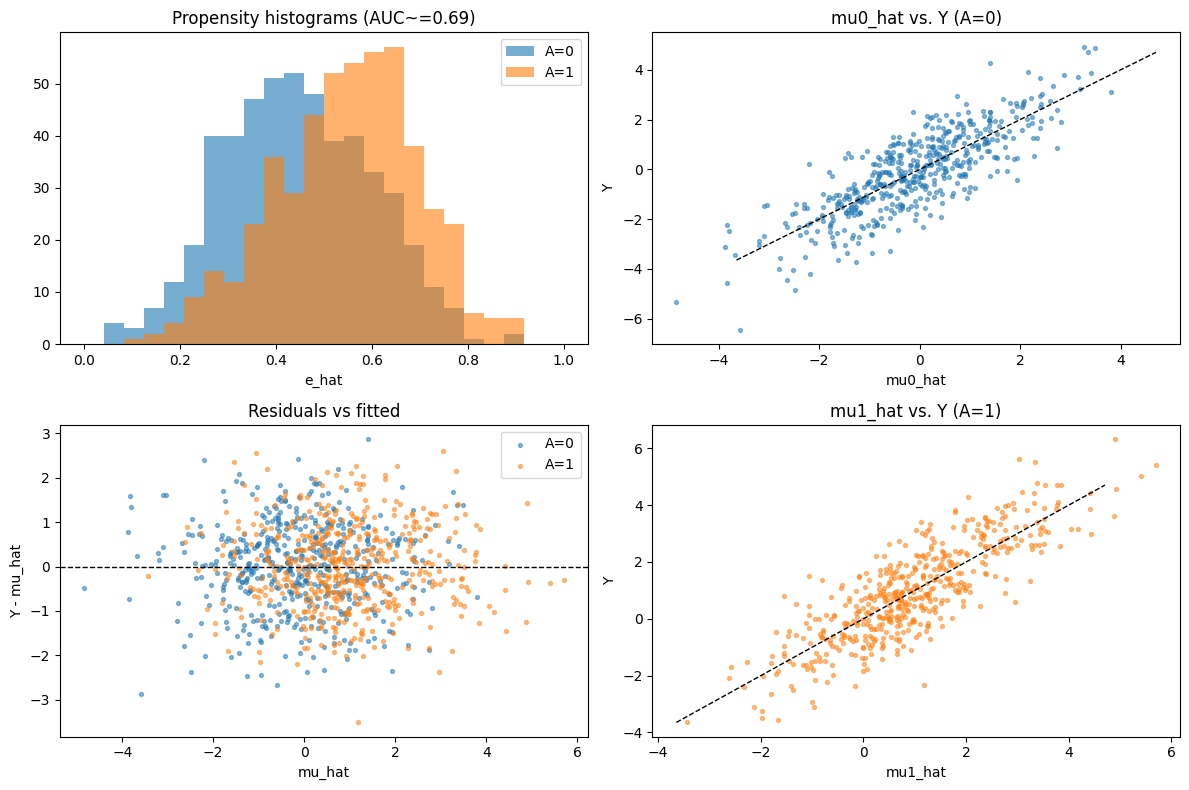

In [5]:
# Re-simulate data using src.py to get X, A, Y for plotting
import importlib.util
import pathlib

src_path = pathlib.Path('src.py').resolve()
spec = importlib.util.spec_from_file_location('src', src_path)
src = importlib.util.module_from_spec(spec)
spec.loader.exec_module(src)

dgp_name = run_cfg['data']['dgp_fn_REGISTRATION']
data_cfg = run_cfg.get('data', {})
misc_cfg = run_cfg.get('misc', {})
run_seed = misc_cfg.get('run_seed')
run_seed = int(run_seed) if run_seed is not None else None
if run_seed is not None:
    seed = src.build_run_seeds(run_seed)["dgp"]
else:
    seed = data_cfg.get('seed', None)
    seed = int(seed) if seed is not None else None
n = int(data_cfg['n'])
dgp_kwargs = data_cfg.get('dgp_kwargs', {})

dgp_fn = src._resolve_from_registry(dgp_name, src._DGP_REGISTRY, 'dgp_fn_REGISTRATION')
if seed is None:
    data = dgp_fn(n=n, **dgp_kwargs)
else:
    data = dgp_fn(n=n, seed=seed, **dgp_kwargs)
A = data['A']
Y = data['Y']

nuisance_diagnostics(e_hat, mu0_hat, mu1_hat, Y, A)


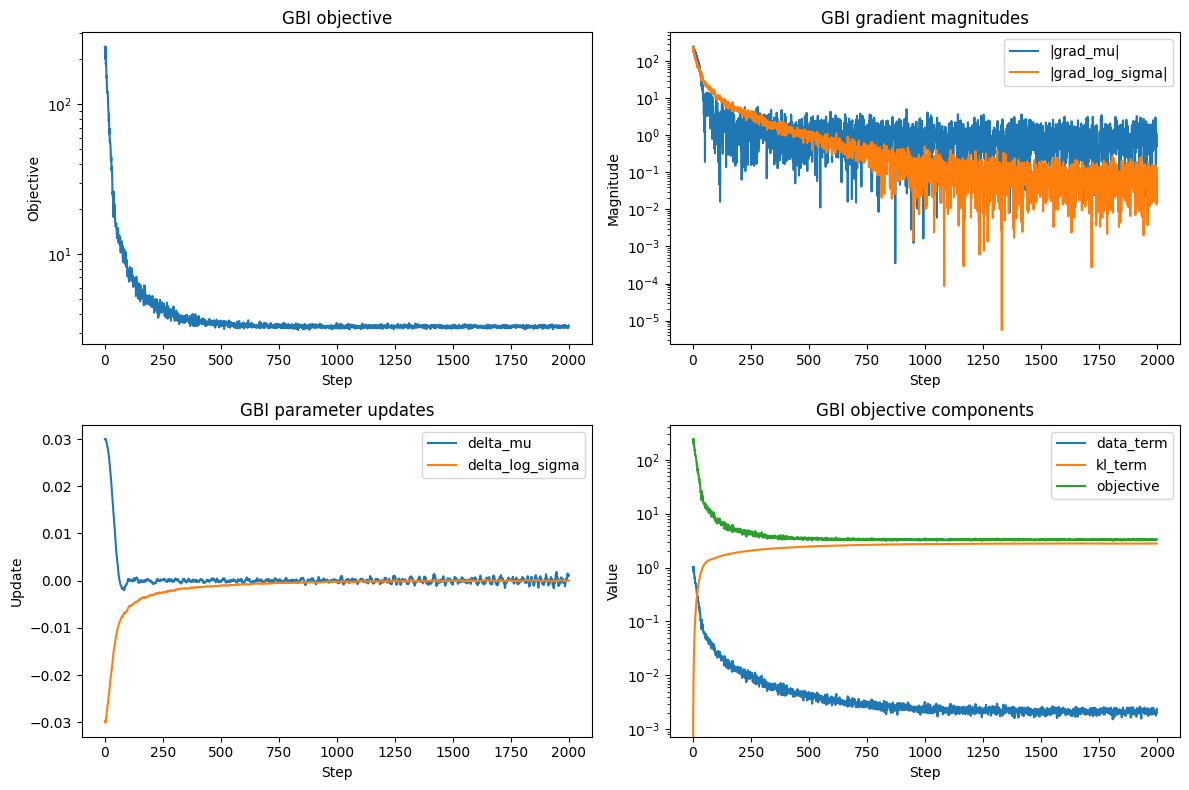

In [6]:
# GBI optimization diagnostics
gbi_diagnostics(history)
